In [1]:
# Predict house prices based on property features so buyers, sellers, and real-estate teams can make informed pricing decisions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
# Create Sample Housing Data

In [4]:
np.random.seed(42)

housing = pd.DataFrame({
    'house_size_sqft': np.random.randint(600, 4000, 500),
    'bedrooms': np.random.randint(1, 6, 500),
    'bathrooms': np.random.randint(1, 4, 500),
    'age_of_house': np.random.randint(0, 40, 500),
    'distance_to_city_miles': np.random.randint(1, 30, 500)
})

# Target variable: house price
housing['price'] = (
    housing['house_size_sqft'] * 150 +
    housing['bedrooms'] * 10000 -
    housing['age_of_house'] * 800 -
    housing['distance_to_city_miles'] * 1200 +
    np.random.randint(-20000, 20000, 500)
)

housing.head()


,house_size_sqft,bedrooms,bathrooms,age_of_house,distance_to_city_miles,price
0,3774,4,2,25,12,575926
1,1460,5,2,31,27,198521
2,1894,2,2,9,29,262709
3,1730,4,3,15,20,250873
4,1695,2,1,6,18,266525


In [5]:
#We are creating fake housing data that mimics real market behavior:

#Bigger houses cost more

#More bedrooms increase price

#Older houses reduce price

#Houses farther from the city are cheaper

In [10]:
#Exploratory Data Analysis 
#This helps us understand which factors influence price.

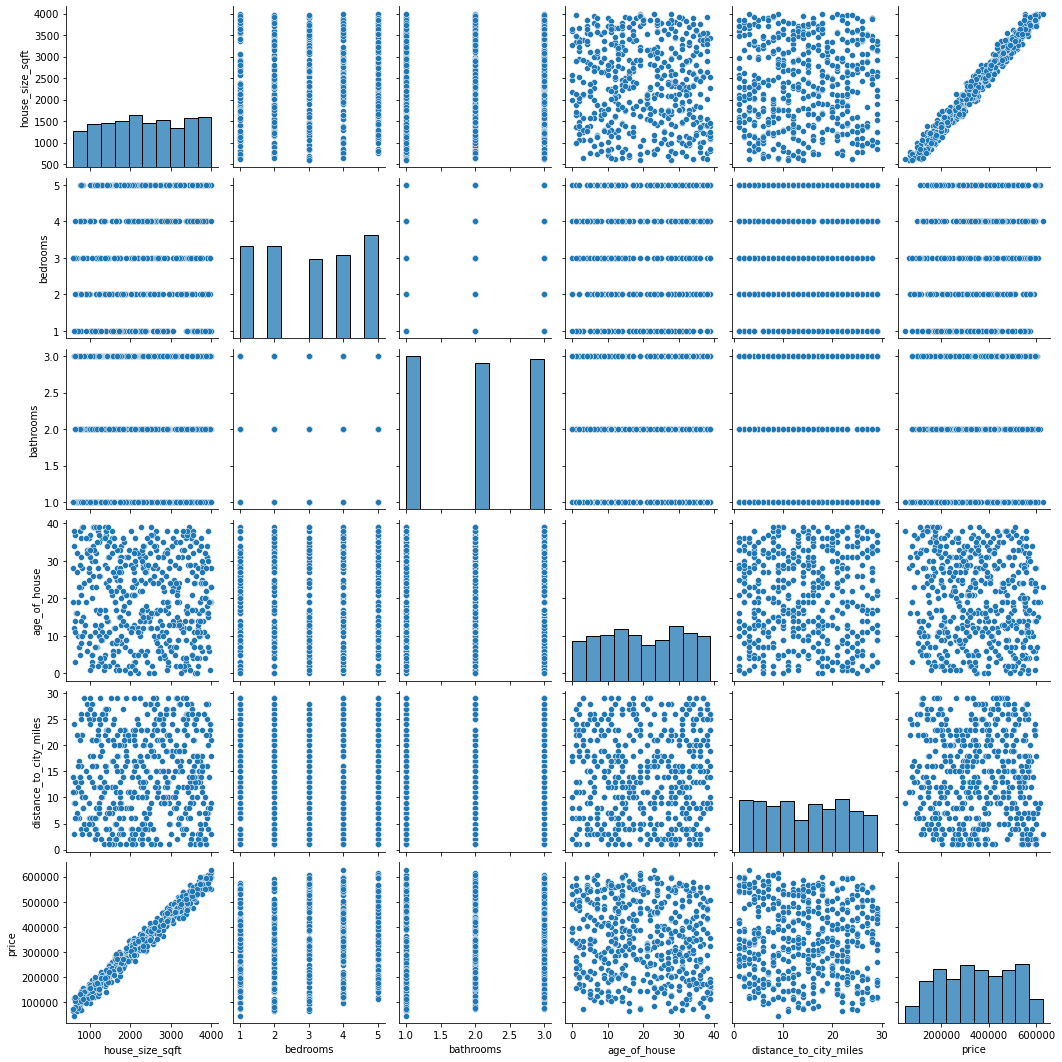

In [7]:
sns.pairplot(housing)
plt.show()


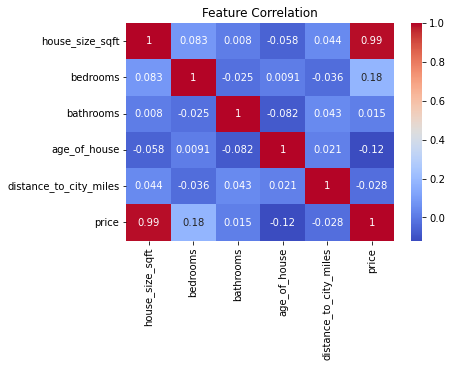

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(housing.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()


In [11]:
#Prepare Data for Modeling

In [12]:
X = housing.drop('price', axis=1)
y = housing['price']


In [13]:
#Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [15]:
#Train on 75% of data, test on unseen 25%.

In [16]:
#Feature Scaling

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [18]:
#Train Linear Regression Model

In [19]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

In [20]:
#Make Predictions

In [21]:
y_pred = model.predict(X_test_scaled)


In [22]:
#Evaluate Model

In [23]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 9717.409159693721
RMSE: 11195.295727657776
R2 Score: 0.9939049993093764


In [24]:
#MAE: Average error in dollars

#RMSE: Penalizes larger mistakes

#R²: How well the model explains prices (closer to 1 is better)

In [25]:
#Feature Importance 
#Shows how each feature increases or decreases price.

In [26]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients


,Feature,Coefficient
0,house_size_sqft,146681.537001
1,bedrooms,14701.547747
2,bathrooms,1404.199941
3,age_of_house,-9273.789531
4,distance_to_city_miles,-10351.750778


In [27]:
#Business Insights

In [29]:
### Business Insights
#- House size has the strongest positive impact on price.
#- Properties closer to the city are priced higher.
#- Older houses tend to have lower prices.
#- The model can help estimate fair market value for listings.
